In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import sys
from pathlib import Path
from src.run_model import run_analysis
from src.config import CSV_PATH
from src.preprocess import load_and_prep_data


================ CLUSTERING SANITY CHECK ================
Regime: controlled
Features used: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Silhouette Score: 0.404
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 1: 332 shots (33.2%)
  Cluster 2: 373 shots (37.3%)
  Cluster 3: 161 shots (16.1%)
  Cluster 4: 133 shots (13.3%)

--- Cluster Means ---
               PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES      ETAU
Cluster_Label                                                                            
3               3.477672  37.583082 -0.000366  1.961619  1.516418  5.724205e+13  0.045923
2               4.149743  39.533137  1.948345  1.991352  0.210047  6.559004e+13  0.042155
1               5.583279  38.393384  1.962578  1.790524  1.830177  7.893287e+13  0.037482
4               2.004975  42.550452  1.489082  0.086901  0.428992  4.498990e+13  0.036148


/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


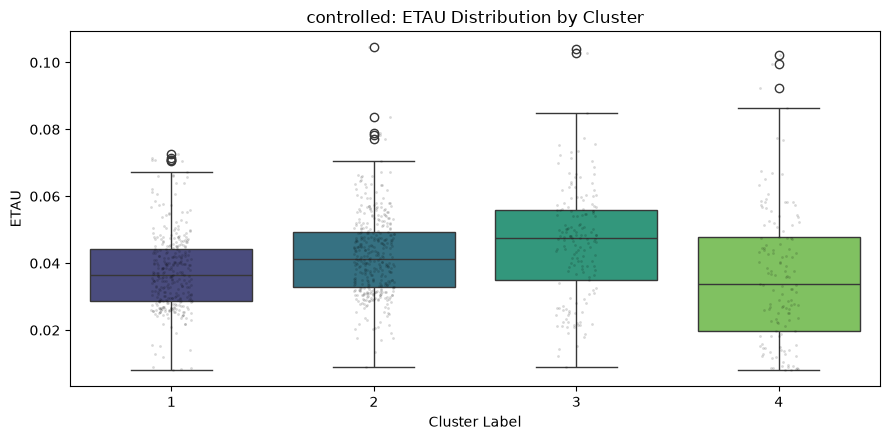


ETAU prediction using KMeans clusters: R^2 = 0.650
ETAU prediction using KMeans clusters: RMSE = 0.008


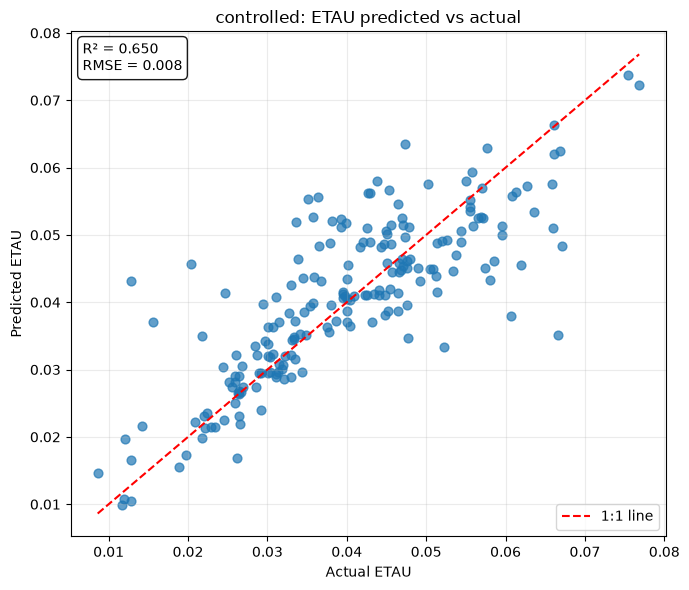

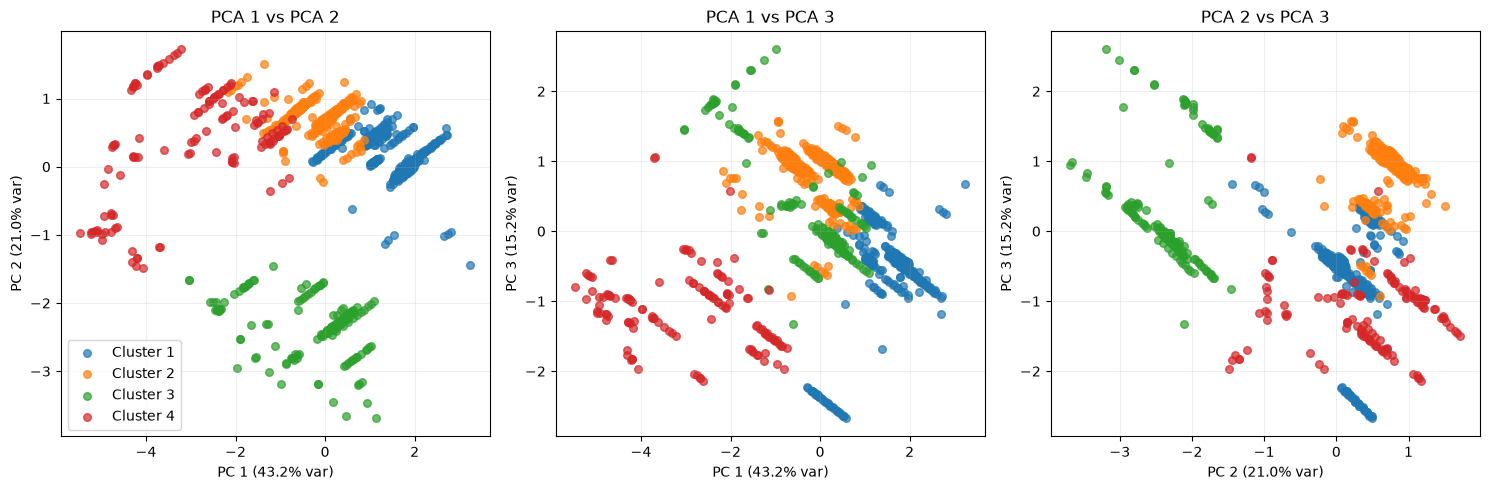

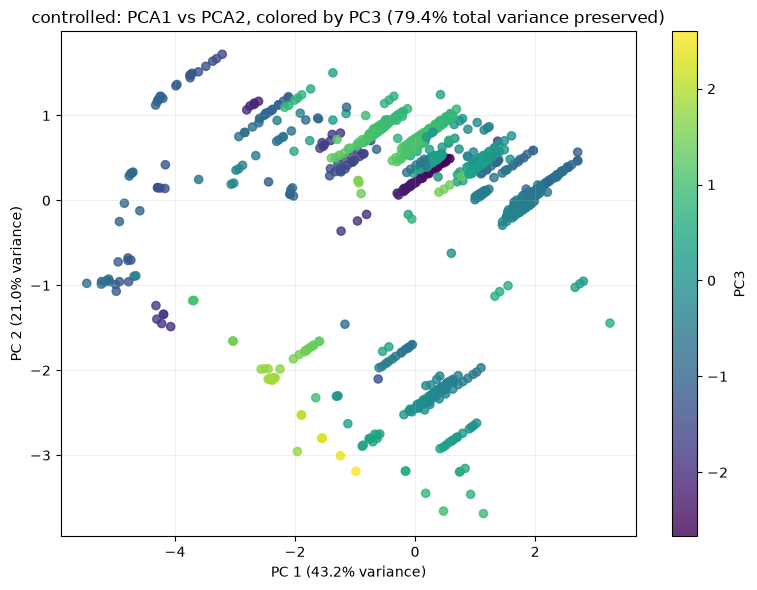

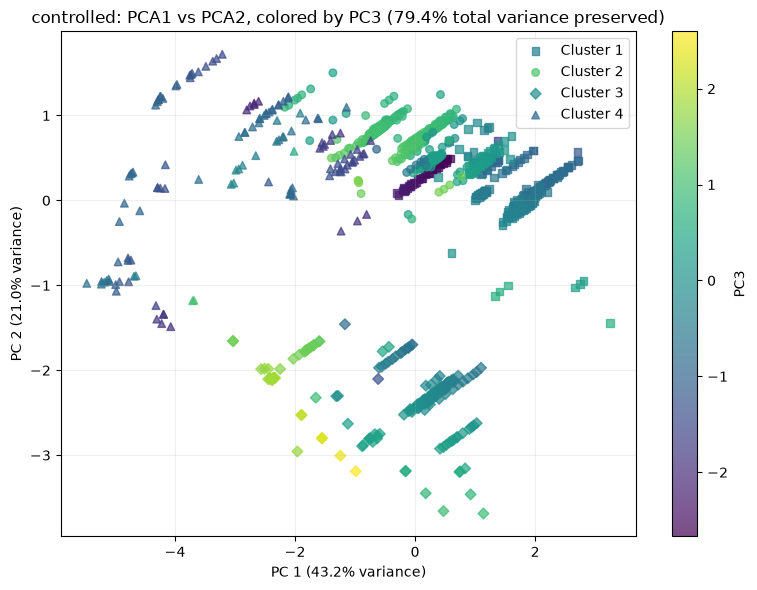


PCA component loadings:
     PBEAM_TOT      BZXR   PBEAM_A   PBEAM_B   PBEAM_C       NES
PC1   0.576492 -0.380970  0.191605  0.394523  0.377011  0.433614
PC2   0.119087  0.298761  0.812328 -0.120882 -0.417629  0.218307
PC3  -0.054168 -0.237802 -0.059785  0.710250 -0.620828 -0.216931


In [2]:

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES",
]

analysis_control = run_analysis(
    feature_cols=controlled_features,
    regime_name="controlled",
)


In [3]:
# Cell 1: load and prepare only the controlled variables


PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES"
]

df_clean_controlled = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=controlled_features,
)

print("Rows:", len(df_clean_controlled))
print("Controlled feature list:", controlled_features)
print("Target column:", "ETAU")

Rows: 1021
Controlled feature list: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Target column: ETAU


================ CLUSTERING SANITY CHECK ================
Regime: controlled
Features used: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Silhouette Score: 0.404
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 1: 332 shots (33.2%)
  Cluster 2: 373 shots (37.3%)
  Cluster 3: 161 shots (16.1%)
  Cluster 4: 133 shots (13.3%)

--- Cluster Means ---
               PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES      ETAU
Cluster_Label                                                                            
3               3.477672  37.583082 -0.000366  1.961619  1.516418  5.724205e+13  0.045923
2               4.149743  39.533137  1.948345  1.991352  0.210047  6.559004e+13  0.042155
1               5.583279  38.393384  1.962578  1.790524  1.830177  7.893287e+13  0.037482
4               2.004975  42.550452  1.489082  0.086901  0.428992  4.498990e+13  0.036148


/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


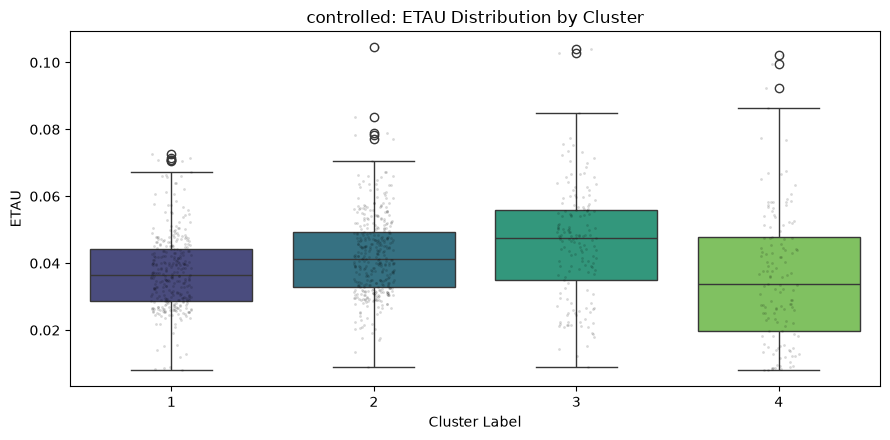


ETAU prediction using KMeans clusters: R^2 = 0.650
ETAU prediction using KMeans clusters: RMSE = 0.008


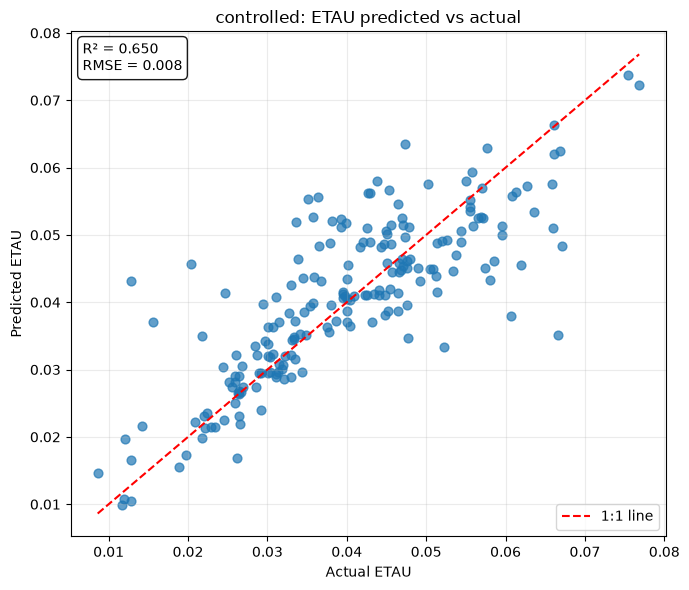

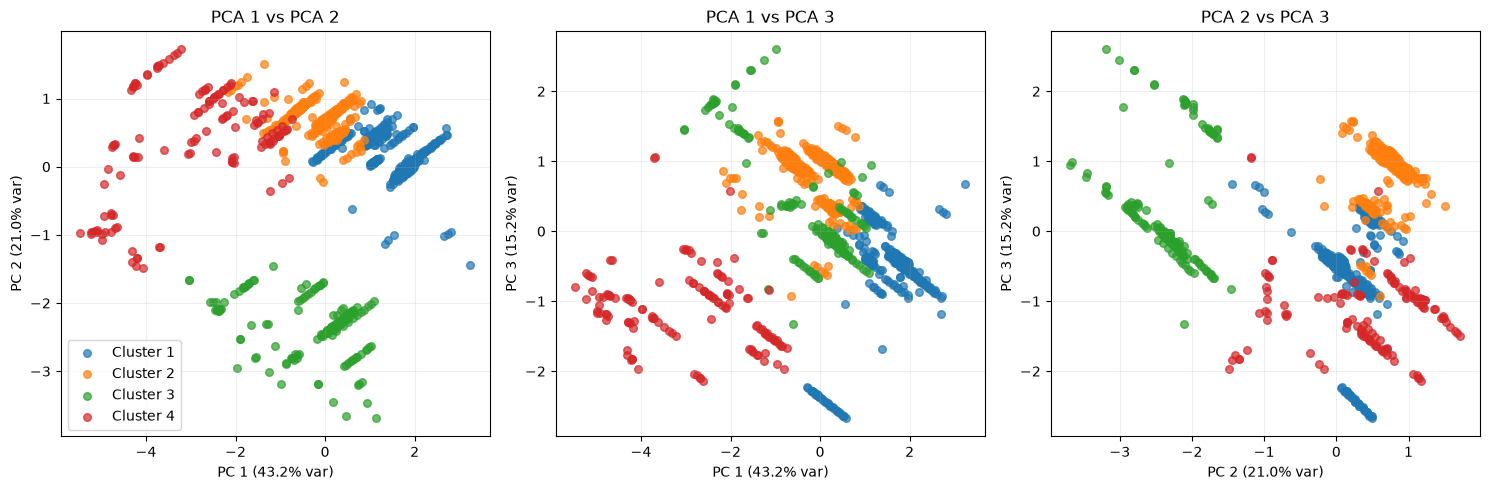

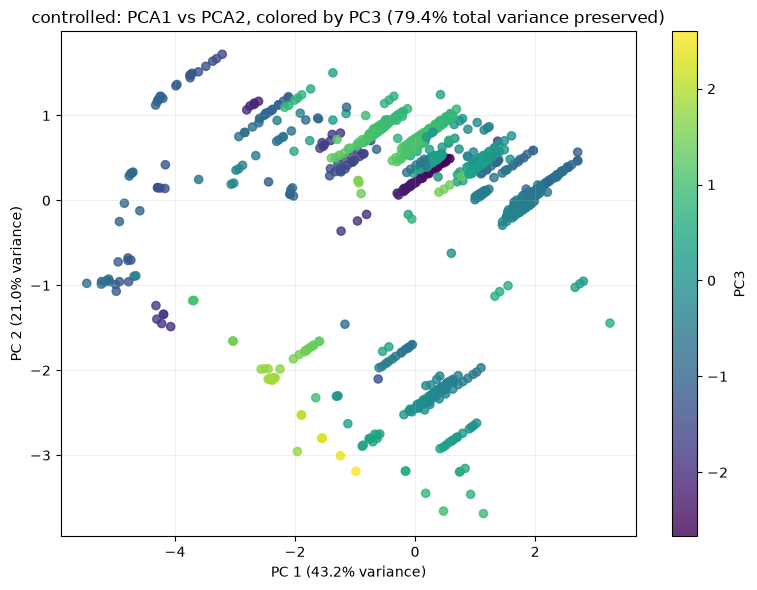

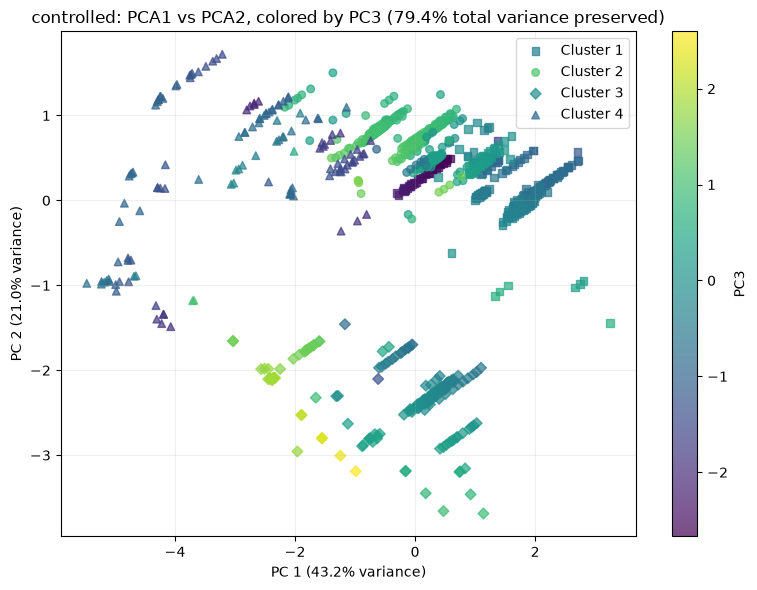


PCA component loadings:
     PBEAM_TOT      BZXR   PBEAM_A   PBEAM_B   PBEAM_C       NES
PC1   0.576492 -0.380970  0.191605  0.394523  0.377011  0.433614
PC2   0.119087  0.298761  0.812328 -0.120882 -0.417629  0.218307
PC3  -0.054168 -0.237802 -0.059785  0.710250 -0.620828 -0.216931
{'regime_name': 'controlled', 'target_col': 'ETAU', 'selected_features': ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES'], 'n_clusters': 4, 'silhouette_score': 0.4035286732438176, 'cluster_counts': {1: 332, 2: 373, 3: 161, 4: 133}, 'cluster_summary':                PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C  \
Cluster_Label                                                       
3               3.477672  37.583082 -0.000366  1.961619  1.516418   
2               4.149743  39.533137  1.948345  1.991352  0.210047   
1               5.583279  38.393384  1.962578  1.790524  1.830177   
4               2.004975  42.550452  1.489082  0.086901  0.428992   

                        NES      ETA

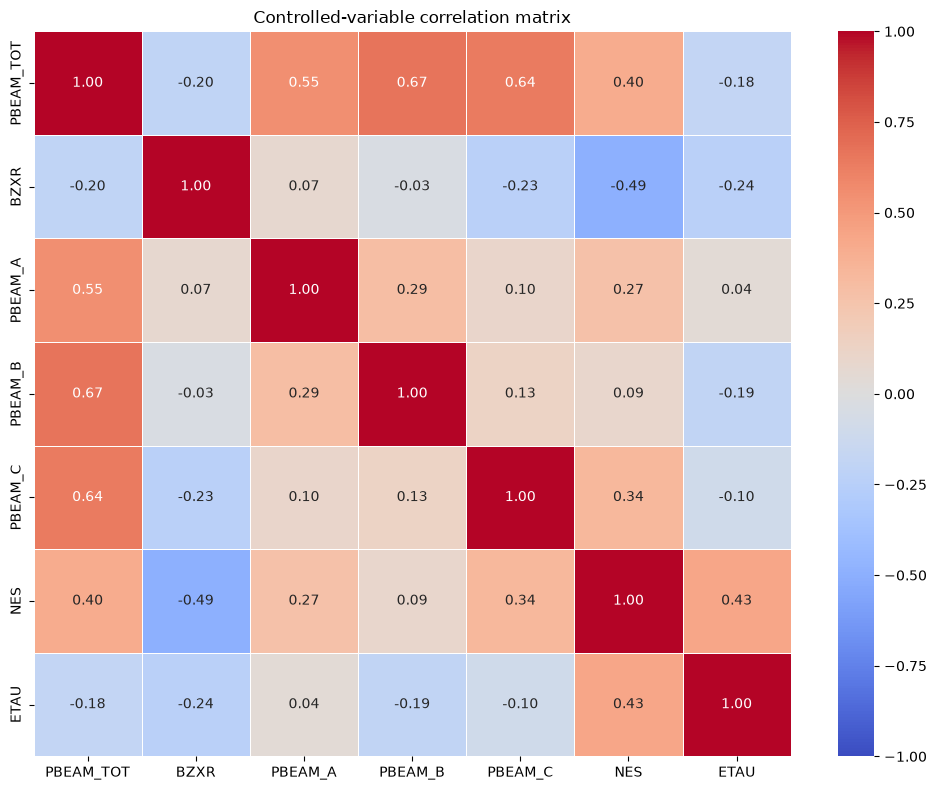

In [4]:
# Controlled regime
from src.run_model import run_analysis
from src.preprocess import plot_correlation_matrix

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES",
]

df_clean_controlled = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=controlled_features,
)

analysis_controlled = run_analysis(
    feature_cols=controlled_features,
    regime_name="controlled",
    n_clusters=4,
)

print(analysis_controlled["report"])
print(analysis_controlled["cluster_summary"])

plot_correlation_matrix(
    df_clean_controlled,
    cols=controlled_features,
    title="Controlled-variable correlation matrix",
)

In [5]:
PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mode_features = [
    "TOTPWR",
    "AVGMODEN",
    "AVGMODEF",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C"
]

target = ['ETAU']

df_clean_mode = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=mode_features,
)

print("Rows:", len(df_clean_mode))
print("Controlled feature list:", mode_features)
print("Target column:", "ETAU")

Rows: 1021
Controlled feature list: ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C']
Target column: ETAU


================ CLUSTERING SANITY CHECK ================
Regime: mode
Features used: ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C']
Silhouette Score: 0.358
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 1: 300 shots (30.0%)
  Cluster 2: 374 shots (37.4%)
  Cluster 3: 162 shots (16.2%)
  Cluster 4: 163 shots (16.3%)

--- Cluster Means ---
                     TOTPWR  AVGMODEN    AVGMODEF   PBEAM_A   PBEAM_B   PBEAM_C      ETAU
Cluster_Label                                                                            
4              3.083968e-11 -1.304356  594.271356 -0.000368  1.961538  1.497812  0.045673
2              1.769463e-11 -2.162251  544.618206  1.950159  1.996450  0.340572  0.042495
3              1.234949e-11 -0.668538  532.342995  1.690820  0.093002  0.795597  0.042392
1              3.062580e-11 -3.849294  633.079464  1.910283  1.943791  1.622538  0.033879


/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


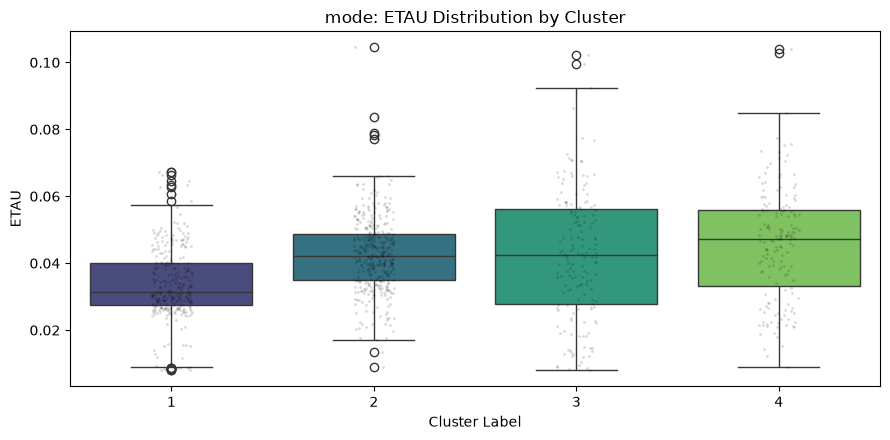


ETAU prediction using KMeans clusters: R^2 = 0.465
ETAU prediction using KMeans clusters: RMSE = 0.010


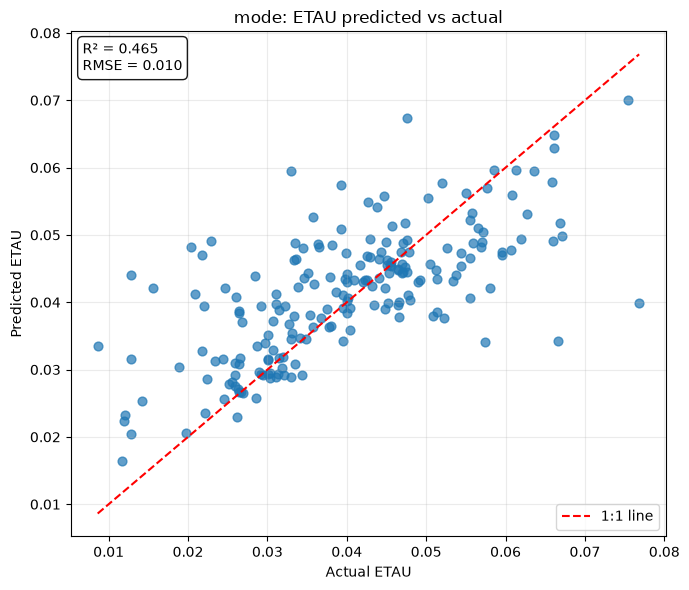

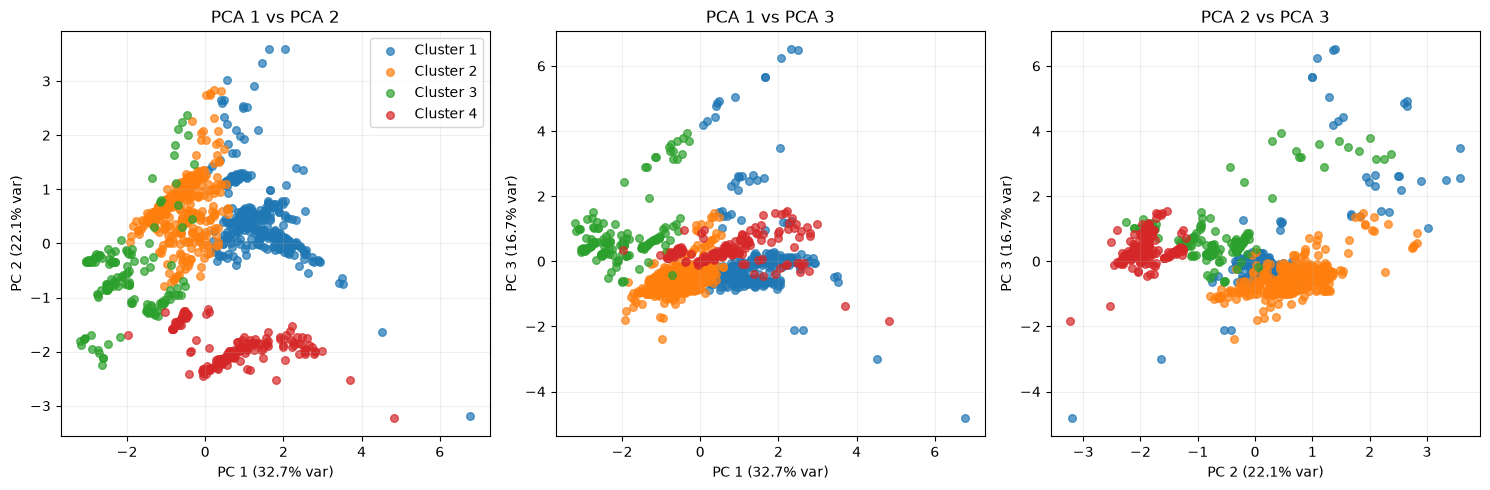

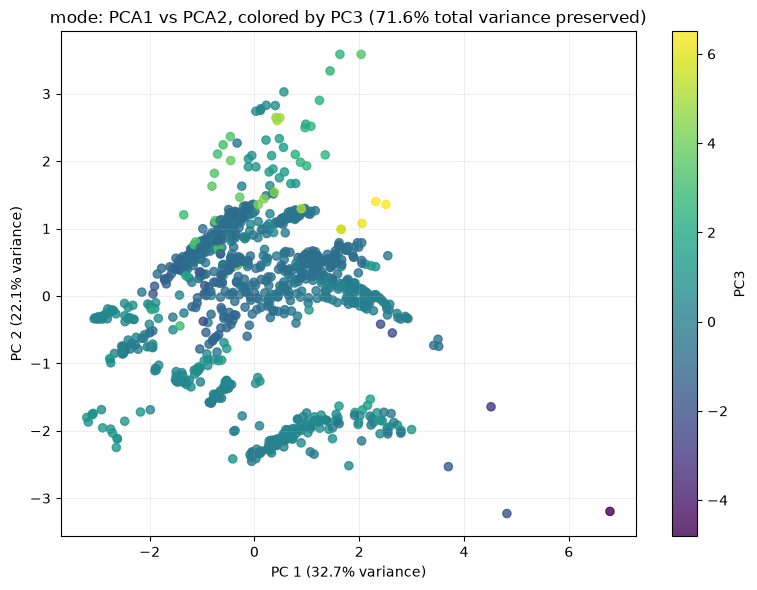

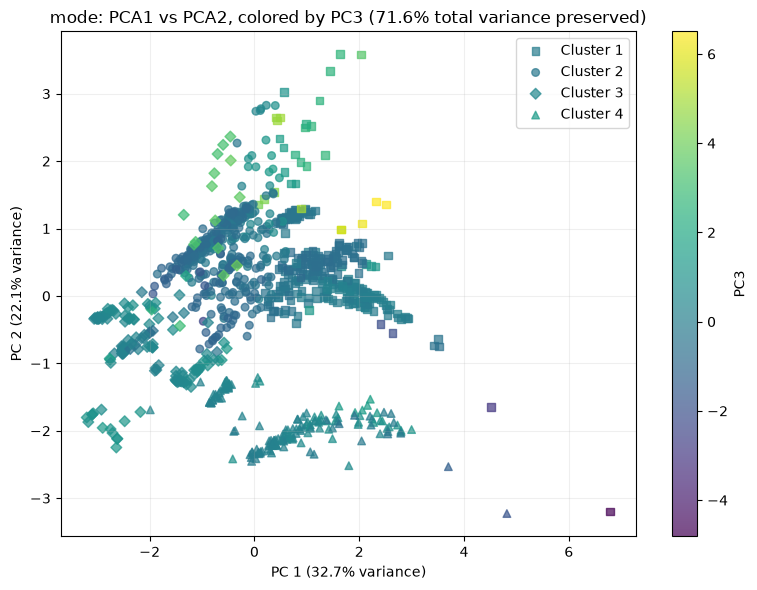


PCA component loadings:
       TOTPWR  AVGMODEN  AVGMODEF   PBEAM_A   PBEAM_B   PBEAM_C
PC1  0.524206 -0.433265  0.416613 -0.102313  0.415390  0.425331
PC2 -0.260266 -0.553222  0.160745  0.630945  0.171376 -0.415821
PC3 -0.297384 -0.160705  0.703590 -0.342035 -0.519582 -0.061194
{'regime_name': 'mode', 'target_col': 'ETAU', 'selected_features': ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C'], 'n_clusters': 4, 'silhouette_score': 0.35806079162552745, 'cluster_counts': {1: 300, 2: 374, 3: 162, 4: 163}, 'cluster_summary':                      TOTPWR  AVGMODEN    AVGMODEF   PBEAM_A   PBEAM_B  \
Cluster_Label                                                           
4              3.083968e-11 -1.304356  594.271356 -0.000368  1.961538   
2              1.769463e-11 -2.162251  544.618206  1.950159  1.996450   
3              1.234949e-11 -0.668538  532.342995  1.690820  0.093002   
1              3.062580e-11 -3.849294  633.079464  1.910283  1.943791   

               

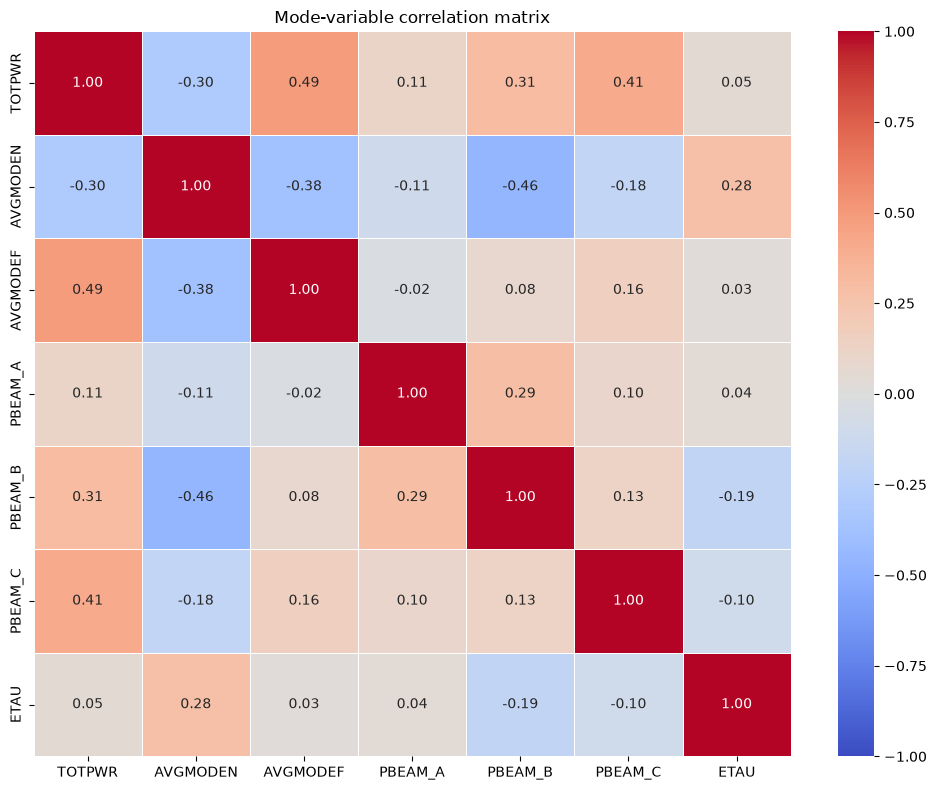

In [6]:
# Mode regime
from src.run_model import run_analysis
from src.preprocess import plot_correlation_matrix

mode_features = [
    "TOTPWR",
    "AVGMODEN",
    "AVGMODEF",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
]

df_clean_mode = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=mode_features,
)

analysis_mode = run_analysis(
    feature_cols=mode_features,
    regime_name="mode",
    n_clusters=4,
)

print(analysis_mode["report"])
print(analysis_mode["cluster_summary"])

plot_correlation_matrix(
    df_clean_mode,
    cols=mode_features,
    title="Mode-variable correlation matrix",
)